In [1]:
print("hi")

hi


In [7]:
import numpy as np
import torch
import os

In [5]:
from omegaconf import OmegaConf 
from src.models import get_model 

cfg_path = 'dualtrack_ft_tus_rec_2025.yaml'
cfg = OmegaConf.load(cfg_path)
cfg.checkpoint = r'D:\Ultra_sound\DualTrack\dualtrack_ft_tus_rec_2025_v3_best.pt'

model = get_model(**cfg)

<All keys matched successfully>


In [45]:
# exclude this
import pandas as pd

data = [
    [0, "sample1", "D:/val_data/frames/050/LH_Par_C_DtP.h5", "val"]
]

df = pd.DataFrame(data, columns=["index", "sweep_id", "processed_sweep_path", "split"])
df.to_csv("metadata.csv", index=False)

In [46]:
# 1-time
import os
import pandas as pd

base_dir = "D:/val_data"
frames_dir = os.path.join(base_dir, "frames")
transfs_dir = os.path.join(base_dir, "transfs")

rows = []

for folder in os.listdir(frames_dir):  # 050, 051, etc.
    frame_subdir = os.path.join(frames_dir, folder)
    trans_subdir = os.path.join(transfs_dir, folder)

    if not os.path.isdir(frame_subdir):
        continue

    for file in os.listdir(frame_subdir):
        if file.endswith(".h5"):
            frame_path = os.path.join(frame_subdir, file)
            trans_path = os.path.join(trans_subdir, file)

            frame_path = os.path.join(frame_subdir, file).replace("\\", "/")
            trans_path = os.path.join(trans_subdir, file).replace("\\", "/")

            # check if matching transform exists
            if not os.path.exists(trans_path):
                print(f"Missing transfs for {file}")
                continue

            sweep_id = f"{folder}_{file.replace('.h5','')}"

            rows.append({
                "sweep_id": sweep_id,
                "raw_tus_rec_frames_path": frame_path,
                "raw_tus_rec_tforms_path": trans_path,
                "split": "val"
            })

df = pd.DataFrame(rows)

# save CSV
df.to_csv("tusrec_metadata.csv", index=False)

print("CSV created with", len(df), "entries")

CSV created with 72 entries


In [48]:
# 1-time
import pandas as pd

# load your existing CSV
df = pd.read_csv("D:/Ultra_sound/DualTrack/processed_data/metadata.csv")

# add index column
df.insert(0, "index", range(len(df)))

# save back
df.to_csv("D:/Ultra_sound/DualTrack/processed_data/metadata_fixed.csv", index=False)

print("Fixed CSV saved!")

ValueError: cannot insert index, already exists

In [8]:
from src.datasets.sweeps_dataset_v2 import SweepsDataset
from src.datasets import sweeps_dataset_v2

print(sweeps_dataset_v2.DATASET_INFO)

ds = SweepsDataset(name='tus-rec', split='val')


print("CSV being used:", ds.metadata.head())
print(len(ds))
print(ds[0]['images'].shape) # print the loaded sweep shape (N_timesteps x H x W) array

{'tus-rec': {'data_csv_path': 'processed_data/metadata.csv'}, 'tus-rec-val': {'data_csv_path': 'processed_data/metadata.csv'}, 'my-dataset-2': {'data_csv_path': '...'}}


Loading dataset: 100%|██████████| 72/72 [00:00<00:00, 196.52it/s]


CSV being used:                                     processed_sweep_path          sweep_id  \
index                                                                        
0      D:\Ultra_sound\DualTrack\processed_data\050_LH...  050_LH_Par_C_DtP   
1      D:\Ultra_sound\DualTrack\processed_data\050_LH...  050_LH_Par_C_PtD   
2      D:\Ultra_sound\DualTrack\processed_data\050_LH...  050_LH_Par_L_DtP   
3      D:\Ultra_sound\DualTrack\processed_data\050_LH...  050_LH_Par_L_PtD   
4      D:\Ultra_sound\DualTrack\processed_data\050_LH...  050_LH_Par_S_DtP   

                      raw_tus_rec_frames_path  \
index                                           
0      D:/val_data/frames/050/LH_Par_C_DtP.h5   
1      D:/val_data/frames/050/LH_Par_C_PtD.h5   
2      D:/val_data/frames/050/LH_Par_L_DtP.h5   
3      D:/val_data/frames/050/LH_Par_L_PtD.h5   
4      D:/val_data/frames/050/LH_Par_S_DtP.h5   

                       raw_tus_rec_tforms_path split  
index                                 

In [9]:
print(ds[0].keys())

dict_keys(['start_idx', 'stop_idx', 'sweep_id', 'dimensions', 'images', 'pixel_to_image', 'spacing', 'tracking', 'original_image_shape', 'calibration', '_extra_sequence_keys', '_extra_h5_keys'])


In [10]:
import h5py

with h5py.File(
    r"processed_data\050_LH_Par_C_DtP.h5",
    "r"
) as f:

    print(list(f.keys()))

    print("spacing:", f["spacing"][:])
    print("dimensions:", f["dimensions"][:])
    print("pixel_to_image:", f["pixel_to_image"][:])

['dimensions', 'images', 'pixel_to_image', 'spacing', 'tracking']
spacing: [0.22938919 0.22097969 1.        ]
dimensions: [640 480   1]
pixel_to_image: [[  0.22938919   0.           0.         -73.28984642]
 [  0.           0.22097969   0.         -52.92463589]
 [  0.           0.           1.           0.        ]
 [  0.           0.           0.           1.        ]]


In [11]:
sample = ds[0]

for k,v in sample.items():

    try:
        print(k, v.shape)
    except:
        print(k, v)

start_idx 0
stop_idx 447
sweep_id 050_LH_Par_C_DtP
dimensions (3,)
images (447, 480, 640)
pixel_to_image (4, 4)
spacing (3,)
tracking (447, 4, 4)
original_image_shape (480, 640)
calibration (4, 4)
_extra_sequence_keys []
_extra_h5_keys []


In [12]:
import torch.nn.functional as F

# normalizing
images = ds[0]['images'].astype(np.float32) / 255

# convert to tensor
images = torch.tensor(images, dtype = torch.float32)        # (N, H, W)
images = images.unsqueeze(1)         # (N, 1, H, W)

images = F.interpolate(
    images,
    size=(256, 256),   # IMPORTANT
    mode='bilinear',
    align_corners=False
)

images = images.unsqueeze(0) 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

images = images.to(device)

In [13]:
model.eval()

DualTrack(
  (global_encoder): SimpleModelForSparseTrackingEstimation(
    (backbone): Sequential(
      (0): VideoResnetWrapperForFeatureMaps(
        (backbone): VideoResnetFeaturesOnly(
          (stem): RStemNoTemporal(
            (0): Conv3d(1, 45, kernel_size=(1, 7, 7), stride=(1, 2, 2), padding=(0, 3, 3), bias=False)
            (1): BatchNorm3d(45, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
            (3): Conv3d(45, 64, kernel_size=(1, 3, 3), stride=(1, 1, 1), padding=(0, 1, 1), bias=False)
            (4): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (5): ReLU(inplace=True)
          )
          (layer1): Sequential(
            (0): BasicBlock(
              (conv1): Sequential(
                (0): Conv3DNoTemporal(64, 64, kernel_size=(1, 3, 3), stride=(1, 1, 1), padding=(0, 1, 1), bias=False)
                (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, tr

In [ ]:
# ignore this cell

seq_len = 16
stride = 4
outputs = []

with torch.no_grad():

    for i in range(0, images.shape[1] - seq_len, stride):

        chunk = images[:, i:i+seq_len]

        out = model({
            "local_encoder_inputs": chunk,
            "global_encoder_inputs": chunk
        })
        print(out)

        # take LAST motion prediction only
        outputs.append(out[0, -1])

outputs = torch.stack(outputs)
pred_xyz = outputs.cpu().numpy()

tensor([[[ 0.0806, -0.0170,  0.0104,  0.0254, -0.0057, -0.0198],
         [ 0.1038, -0.0262,  0.0097, -0.0041,  0.0057, -0.0137],
         [ 0.1108, -0.0344, -0.0042,  0.0073,  0.0074, -0.0167],
         [ 0.0571, -0.0234,  0.0103,  0.0260, -0.0199,  0.0053],
         [ 0.1327, -0.0498, -0.0184, -0.0085,  0.0015, -0.0124],
         [ 0.1221, -0.0479, -0.0196, -0.0116, -0.0017, -0.0071],
         [ 0.0852, -0.0433, -0.0382, -0.0244, -0.0024,  0.0229],
         [ 0.0571, -0.0361,  0.0400,  0.0035,  0.0046,  0.0389],
         [ 0.0612, -0.0297,  0.0641,  0.0309, -0.0059,  0.0190],
         [ 0.0518, -0.0351,  0.0736,  0.0306, -0.0136,  0.0403],
         [ 0.0471, -0.0305,  0.0494,  0.0120, -0.0076,  0.0442],
         [ 0.0504, -0.0355,  0.0524,  0.0176, -0.0126,  0.0368],
         [ 0.0458, -0.0286,  0.0151,  0.0086, -0.0077,  0.0343],
         [ 0.0650, -0.0295, -0.0065, -0.0089, -0.0045,  0.0222],
         [ 0.0906, -0.0362,  0.0184, -0.0040, -0.0031,  0.0167]]])
tensor([[[ 1.1423e-01, 

In [ ]:
# ignore this cell

with torch.no_grad():

    out = model({
        "local_encoder_inputs": images,
        "global_encoder_inputs": images
    })

print(out.shape)

pred = out[0].detach().cpu().numpy()

NameError: name 'torch' is not defined

In [ ]:
seq_len = 16
rel_poses = []

with torch.no_grad():
    for i in range(len(images[0]) - seq_len + 1):
        chunk = images[:, i:i+seq_len]   # (1, 16, 1, H, W)
        out = model({
            "local_encoder_inputs": chunk,
            "global_encoder_inputs": chunk
        })
        print(out)
        # Take only the LAST predicted delta — it has full 16-frame context
        rel_poses.append(out[0, -1].cpu().numpy())   # (6,)

pred = np.array(rel_poses)   # (N-15, 6)

tensor([[[ 0.0806, -0.0170,  0.0104,  0.0254, -0.0057, -0.0198],
         [ 0.1038, -0.0262,  0.0097, -0.0041,  0.0057, -0.0137],
         [ 0.1108, -0.0344, -0.0042,  0.0073,  0.0074, -0.0167],
         [ 0.0571, -0.0234,  0.0103,  0.0260, -0.0199,  0.0053],
         [ 0.1327, -0.0498, -0.0184, -0.0085,  0.0015, -0.0124],
         [ 0.1221, -0.0479, -0.0196, -0.0116, -0.0017, -0.0071],
         [ 0.0852, -0.0433, -0.0382, -0.0244, -0.0024,  0.0229],
         [ 0.0571, -0.0361,  0.0400,  0.0035,  0.0046,  0.0389],
         [ 0.0612, -0.0297,  0.0641,  0.0309, -0.0059,  0.0190],
         [ 0.0518, -0.0351,  0.0736,  0.0306, -0.0136,  0.0403],
         [ 0.0471, -0.0305,  0.0494,  0.0120, -0.0076,  0.0442],
         [ 0.0504, -0.0355,  0.0524,  0.0176, -0.0126,  0.0368],
         [ 0.0458, -0.0286,  0.0151,  0.0086, -0.0077,  0.0343],
         [ 0.0650, -0.0295, -0.0065, -0.0089, -0.0045,  0.0222],
         [ 0.0906, -0.0362,  0.0184, -0.0040, -0.0031,  0.0167]]])
tensor([[[ 1.0328e-01, 

In [10]:
pred_xyz = pred
print(pred_xyz.shape)
print(np.mean(np.abs(pred_xyz[:,3:])))

(432, 6)
0.018284112


In [ ]:
from scipy.spatial.transform import Rotation as R
import numpy as np

gt = ds[0]['tracking']   # (N, 4, 4)
gt_xyz = gt[15:, :3, 3]

# IMPORTANT:
# start from GT frame 15 pose
T_global = gt[15].copy()

trajectory = []

trajectory.append(
    T_global[:3,3].copy()
)

for p in pred:

    tx, ty, tz, rx, ry, rz = p

    # rotation vector -> rotation matrix
    R_mat = R.from_rotvec(
        [rx, ry, rz]
    ).as_matrix()

    # build relative transform
    T_rel = np.eye(4)

    T_rel[:3,:3] = R_mat
    T_rel[:3,3] = [tx,ty,tz]

    # compose transforms
    T_global = T_global @ T_rel

    # store global xyz
    trajectory.append(
        T_global[:3,3].copy()
    )

pred_traj = np.array(trajectory)

print(pred_traj.shape)
print(gt_xyz.shape)

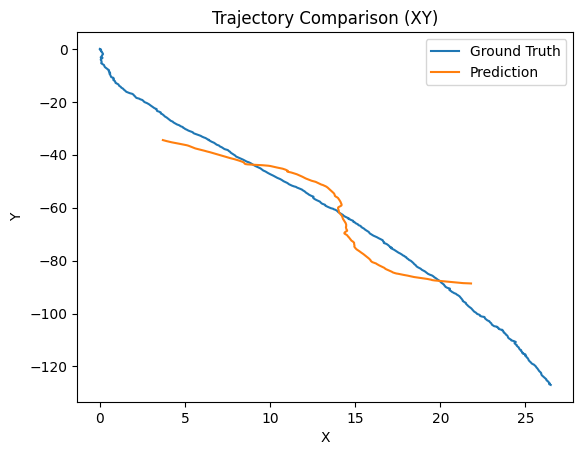

In [ ]:
import matplotlib.pyplot as plt

plt.plot(gt_xyz[:,0], gt_xyz[:,1], label="Ground Truth")
plt.plot(pred_traj[:,0], pred_traj[:,1], label="Prediction")

plt.legend()
plt.title("Trajectory Comparison (XY)")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

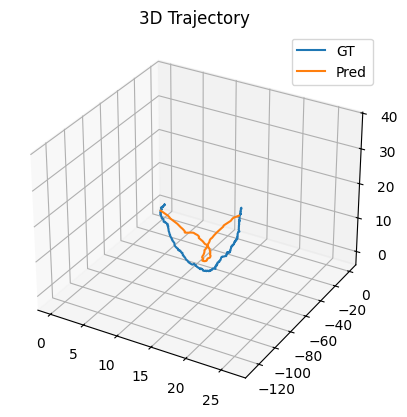

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(gt_xyz[:,0], gt_xyz[:,1], gt_xyz[:,2], label="GT")
ax.plot(pred_traj[:,0], pred_traj[:,1], pred_traj[:,2], label="Pred")

ax.legend()
plt.title("3D Trajectory")
plt.show()

In [75]:
import pandas as pd

n = min(len(gt_xyz), len(pred_traj))

for axis, name in enumerate(['X', 'Y', 'Z']):
    err = np.abs(gt_xyz[:n, axis] - pred_traj[:n, axis])
    print(f"{name} MAE: {err.mean():.4f}")

# Step 4: Check raw relative GT vs raw model output
gt_rel = np.array([
    (np.linalg.inv(gt[i]) @ gt[i+1])[:3, 3]
    for i in range(len(gt)-1)
])
print("GT rel translation stats:\n", pd.DataFrame(gt_rel, columns=['tx','ty','tz']).describe())
print("Pred rel translation stats:\n", pd.DataFrame(pred[:,:3], columns=['tx','ty','tz']).describe())

X MAE: 13.3886
Y MAE: 48.3856
Z MAE: 6.5292
GT rel translation stats:
                tx          ty          tz
count  446.000000  446.000000  446.000000
mean     0.302303   -0.003115    0.010820
std      0.123934    0.034581    0.136603
min     -0.121027   -0.104868   -0.494506
25%      0.225137   -0.025331   -0.079991
50%      0.296938   -0.002017    0.025193
75%      0.366969    0.017914    0.114871
max      0.768070    0.098482    0.288344
Pred rel translation stats:
                tx          ty          tz
count  432.000000  432.000000  432.000000
mean     0.157745   -0.011085   -0.011440
std      0.042016    0.014111    0.036305
min      0.001647   -0.055210   -0.130955
25%      0.131772   -0.020452   -0.027400
50%      0.157690   -0.010906   -0.013764
75%      0.185374   -0.001448   -0.001975
max      0.268975    0.027759    0.272796


In [56]:
gt_rel_all = np.array([
    (np.linalg.inv(gt[i]) @ gt[i+1])[:3, 3] 
    for i in range(len(gt)-1)
])

print("=== GT relative translations ===")
print(f"  tx: {gt_rel_all[:,0].mean():.4f} ± {gt_rel_all[:,0].std():.4f}")
print(f"  ty: {gt_rel_all[:,1].mean():.4f} ± {gt_rel_all[:,1].std():.4f}")
print(f"  tz: {gt_rel_all[:,2].mean():.4f} ± {gt_rel_all[:,2].std():.4f}")

print("=== Predicted relative translations ===")
print(f"  tx: {pred[:,0].mean():.4f} ± {pred[:,0].std():.4f}")
print(f"  ty: {pred[:,1].mean():.4f} ± {pred[:,1].std():.4f}")
print(f"  tz: {pred[:,2].mean():.4f} ± {pred[:,2].std():.4f}")

print("=== GT relative rotations (rotvec) ===")
gt_rot_all = np.array([
    R.from_matrix((np.linalg.inv(gt[i]) @ gt[i+1])[:3,:3]).as_rotvec()
    for i in range(len(gt)-1)
])
print(f"  rx: {gt_rot_all[:,0].mean():.5f} ± {gt_rot_all[:,0].std():.5f}")
print(f"  ry: {gt_rot_all[:,1].mean():.5f} ± {gt_rot_all[:,1].std():.5f}")
print(f"  rz: {gt_rot_all[:,2].mean():.5f} ± {gt_rot_all[:,2].std():.5f}")

print("=== Predicted relative rotations ===")
print(f"  rx: {pred[:,3].mean():.5f} ± {pred[:,3].std():.5f}")
print(f"  ry: {pred[:,4].mean():.5f} ± {pred[:,4].std():.5f}")
print(f"  rz: {pred[:,5].mean():.5f} ± {pred[:,5].std():.5f}")

=== GT relative translations ===
  tx: 0.3023 ± 0.1238
  ty: -0.0031 ± 0.0345
  tz: 0.0108 ± 0.1364
=== Predicted relative translations ===
  tx: 0.1577 ± 0.0420
  ty: -0.0111 ± 0.0141
  tz: -0.0114 ± 0.0363
=== GT relative rotations (rotvec) ===
  rx: 0.00042 ± 0.00090
  ry: 0.00042 ± 0.00067
  rz: -0.00022 ± 0.00100
=== Predicted relative rotations ===
  rx: -0.01571 ± 0.01866
  ry: -0.00205 ± 0.00847
  rz: -0.02636 ± 0.02086


In [76]:
import numpy as np

translation_error = np.linalg.norm(
    gt_xyz - pred_traj_aligned,
    axis=1
)

print("Mean Translation Error:", translation_error.mean())
print("RMSE:", np.sqrt(np.mean(translation_error**2)))

Mean Translation Error: 19.21146067115038
RMSE: 21.9422281121514


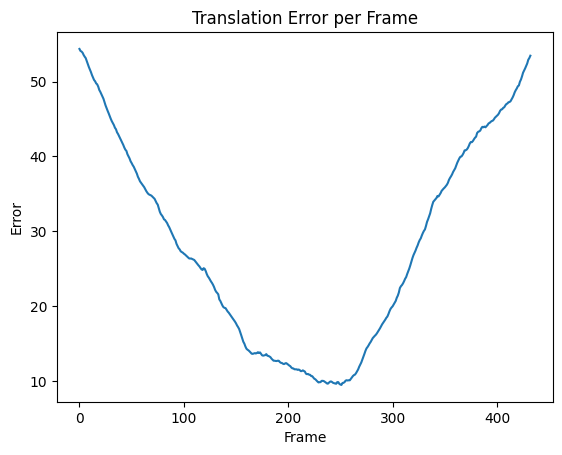

In [17]:
import matplotlib.pyplot as plt

plt.plot(translation_error)
plt.title("Translation Error per Frame")
plt.xlabel("Frame")
plt.ylabel("Error")
plt.show()